# Análisis de Resultados: Optimización de Microgrid con PPO

Este notebook tiene como objetivo analizar exhaustivamente el rendimiento de un agente de Aprendizaje por Refuerzo Profundo (Proximal Policy Optimization - PPO) entrenado para la gestión energética de una microrred.

La microrred está compuesta por:
* **Red Eléctrica (Grid):** Compra y venta de energía con precios variables.
* **Carga (Load):** Demanda energética del edificio.
* **Generación Renovable (PV):** Paneles solares.
* **Sistema de Almacenamiento (Batería):** Batería de 200 kWh.

**Objetivo del Agente:** Minimizar el coste económico operativo anual (maximizando la recompensa) decidiendo en cada hora cuánta energía cargar o descargar de la batería, respetando las restricciones físicas del sistema y evitando penalizaciones por vaciado.

### Imports Necesarios

In [25]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from stable_baselines3 import PPO

# Añadir ruta al entorno custom y pymgrid (Ajusta según tu estructura)
ruta_base = Path(os.getcwd()).parent.parent
sys.path.append(str(ruta_base))

from custom_env_continuous_v2 import CustomEnvContinuousv2
from pymgrid.modules import GridModule, BatteryModule, LoadModule, RenewableModule
from pymgrid import Microgrid

import warnings
warnings.filterwarnings("ignore")

# Configuración visual para las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

### Recreamos el entorno

In [26]:
# 1. Cargar Datos
ruta_precios = ruta_base / "OBJETIVO1" / 'data' / 'external' / 'precio2025-peninsula.csv'
ruta_load = ruta_base / "OBJETIVO1" / 'data' / 'raw' / 'load' / 'RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv'
ruta_pv = ruta_base / "OBJETIVO1" / 'data' / 'processed' / 'pv_generacion_corregida_kw.csv'

df_precios = pd.read_csv(ruta_precios, sep=';')
precios_kwh = df_precios.sort_values('datetime')['value'].values / 1000.0
load_series = pd.read_csv(ruta_load).iloc[:, -1].values
pv_series = pd.read_csv(ruta_pv).iloc[:, -1].values

min_len = min(len(precios_kwh), len(load_series), len(pv_series), 8760)

# 2. Configurar Entorno Base (Igual que en entrenamiento)
grid_ts = pd.DataFrame({
    'import_price': precios_kwh[:min_len], 
    'export_price': precios_kwh[:min_len] * 0.5, 
    'co2_per_kwh': 0.0
})
grid = GridModule(max_import=200.0, max_export=200.0, time_series=grid_ts)
battery = BatteryModule(min_capacity=10.0, max_capacity=200.0, max_charge=50.0, max_discharge=50.0, efficiency=0.9, init_soc=0.5)
load = LoadModule(time_series=load_series[:min_len])
pv = RenewableModule(time_series=pv_series[:min_len])
mg = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])

env_eval = CustomEnvContinuousv2(
    pymgrid_network=mg, horizon=8760, reward_scale_C=91.88,
    low_soc_penalty=2.0, low_soc_threshold=0.20,
    net_load_min=-40.64, net_load_max=62.45, price_min=0.02, price_max=0.425
)

import optuna
from stable_baselines3 import PPO

path_study=ruta_base / "OBJETIVO1" / "PPO"
# 1. Conectar a la base de datos de Optuna
study_name = "ppo_microgrid_v1" # Tu nuevo nombre de estudio
ruta=ruta_base / "OBJETIVO1" / "PPO"
storage_name = f"sqlite:///{path_study}/optuna_ppo_v1.db"

# Cargamos el estudio
study = optuna.load_study(study_name=study_name, storage=storage_name)

# Obtenemos el mejor trial
best_trial = study.best_trial
print(f"El mejor modelo se encontró en el Trial número: {best_trial.number}")
print(f"Mejor recompensa media (Reward): {best_trial.value:.2f}")

# 2. Construir la ruta dinámica al mejor modelo guardado
ruta_logs = ruta_base / "OBJETIVO1" / "PPO"  / "logs" / "logs_optuna_PPO_v1_fast"
model_path = ruta_logs / f"trial_{best_trial.number}" / "best_model.zip"

# 3. Cargar el modelo
if model_path.exists():
    model = PPO.load(model_path)
    print(f"¡Modelo cargado exitosamente desde: {model_path}!")
else:
    print(f"Error: No se encontró el archivo {model_path}.")

El mejor modelo se encontró en el Trial número: 32
Mejor recompensa media (Reward): -278.10
¡Modelo cargado exitosamente desde: c:\Users\nerea\Desktop\MASTER_IA\RETO3\CODE\Reto3_MicroRedes\OBJETIVO1\PPO\logs\logs_optuna_PPO_v1_fast\trial_32\best_model.zip!


## 1. Evolución del Entrenamiento
Analizamos si el agente ha convergido. Una caída en la entropía indica que el agente se ha vuelto más "seguro" de sus decisiones (ha pasado de explorar a explotar la política).

In [27]:
# --- GENERACIÓN DE MATRIZ DE COSTES PARA PPO ---
import numpy as np

N_SIMULACIONES = 20  # Número de semillas para robustez
resultados_ppo = []

print(f"Iniciando {N_SIMULACIONES} evaluaciones de un año completo...")

for i in range(N_SIMULACIONES):
    obs, _ = env_eval.reset(seed=i) # Variamos la semilla
    coste_anual = 0
    done = False
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_eval.step(action)
        
        # Extraemos el coste real del info (asumiendo que tu env lo da)
        # Si no, acumulamos el coste según tu lógica de recompensa
        coste_anual += info.get('cost', 0) 
        
        done = terminated or truncated
    
    resultados_ppo.append(coste_anual)
    print(f"Simulación {i+1}: Coste = {coste_anual:.2f} €")

# Guardar para comparar con Q-Learning
df_ppo = pd.DataFrame(resultados_ppo, columns=['coste_anual'])
df_ppo.to_csv("resultados_estadisticos_ppo.csv", index=False)

Iniciando 20 evaluaciones de un año completo...
Simulación 1: Coste = 25548.26 €
Simulación 2: Coste = 25551.79 €
Simulación 3: Coste = 25551.79 €
Simulación 4: Coste = 25551.79 €
Simulación 5: Coste = 25551.79 €
Simulación 6: Coste = 25551.79 €
Simulación 7: Coste = 25551.79 €
Simulación 8: Coste = 25551.79 €
Simulación 9: Coste = 25551.79 €
Simulación 10: Coste = 25551.79 €
Simulación 11: Coste = 25551.79 €
Simulación 12: Coste = 25551.79 €
Simulación 13: Coste = 25551.79 €
Simulación 14: Coste = 25551.79 €
Simulación 15: Coste = 25551.79 €
Simulación 16: Coste = 25551.79 €
Simulación 17: Coste = 25551.79 €
Simulación 18: Coste = 25551.79 €
Simulación 19: Coste = 25551.79 €
Simulación 20: Coste = 25551.79 €


## 2. Análisis Estadístico de Resultados PPO

Dado que el entorno y el punto de inicio pueden tener cierta estocasticidad, hemos ejecutado el modelo durante $N$ simulaciones (años completos). A continuación, analizamos la distribución del **Coste Operativo Anual**.

Siguiendo las directrices del análisis de rendimiento estadístico, calcularemos:
* **Media y Desviación Estándar:** Para conocer el coste esperado y su variabilidad.
* **Percentiles 5 y 95 (Intervalo de Tolerancia Empírico):** Nos indica el rango en el que caerán el 90% de los años operativos. Si este rango es estrecho, nuestro agente es muy **robusto**.

 RESUMEN ESTADÍSTICO DE PPO (20 Simulaciones)
Coste Medio Anual:         25551.61 €
Desviación Estándar:           0.79 €
Intervalo (P5 - P95):    [25551.61 € , 25551.79 €]
Mínimo - Máximo:         [25548.26 € , 25551.79 €]
------------------------------------------------------------


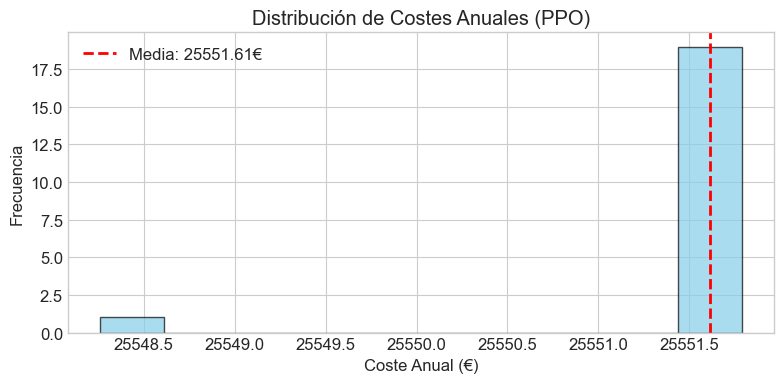

In [28]:
import scipy.stats as stats

# Convertimos a numpy array para facilitar cálculos
costes = df_ppo['coste_anual'].values

media_ppo = np.mean(costes)
std_ppo = np.std(costes, ddof=1)
p5_ppo = np.percentile(costes, 5)
p95_ppo = np.percentile(costes, 95)
min_ppo = np.min(costes)
max_ppo = np.max(costes)

print(f"{'='*60}")
print(f" RESUMEN ESTADÍSTICO DE PPO ({N_SIMULACIONES} Simulaciones)")
print(f"{'='*60}")
print(f"Coste Medio Anual:       {media_ppo:>10.2f} €")
print(f"Desviación Estándar:     {std_ppo:>10.2f} €")
print(f"Intervalo (P5 - P95):    [{p5_ppo:.2f} € , {p95_ppo:.2f} €]")
print(f"Mínimo - Máximo:         [{min_ppo:.2f} € , {max_ppo:.2f} €]")
print(f"{'-'*60}")

# Breve visualización de la distribución
plt.figure(figsize=(8, 4))
plt.hist(costes, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(media_ppo, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_ppo:.2f}€')
plt.title('Distribución de Costes Anuales (PPO)')
plt.xlabel('Coste Anual (€)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Dinámica de la Política: Análisis de una Semana Específica

Para entender el comportamiento del agente, simulamos un único episodio (1 año) de forma determinista y extraemos el registro horario. Posteriormente, graficamos una semana representativa (por ejemplo, en verano) para observar la correlación entre:
1. El precio de la energía.
2. La carga neta (Demanda - Generación Fotovoltaica).
3. Las acciones del agente (Carga/Descarga).
4. El Estado de Carga (SoC) de la batería.

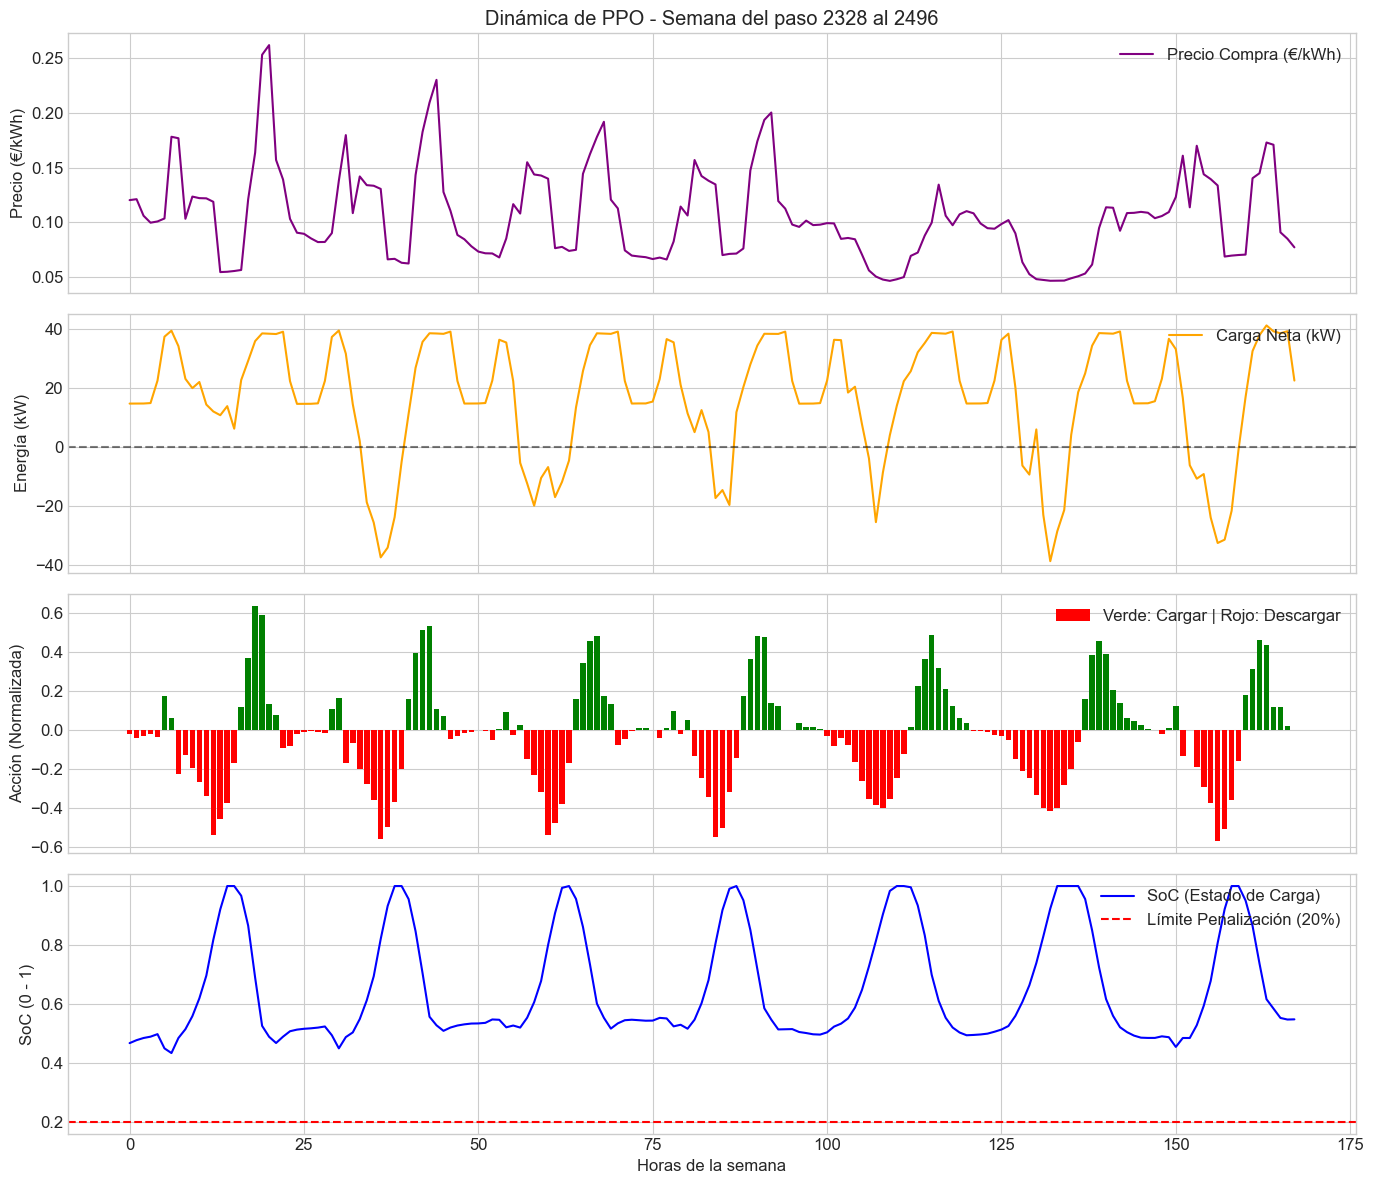

In [37]:
# 1. Ejecutar un episodio completo trackeando las variables
obs, _ = env_eval.reset(seed=42)
done = False

# Listas para guardar la historia
hist_actions = []
hist_soc = []
hist_costes = []

# Extraemos la carga neta real de los datos ya cargados para graficar
net_load_series = load_series[:min_len] - pv_series[:min_len]

paso = 0
while not done:
    # Usamos deterministic=True para ver la "mejor" decisión de la red
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_eval.step(action)
    
    hist_actions.append(action[0])
    # Suponiendo que el SoC de la batería se puede rastrear por el módulo o asumiendo
    # que tu observación lo contiene. Usamos el objeto battery de pymgrid:
    #hist_soc.append(battery.soc) ANTES ERA ESTO
    hist_soc.append(info['soc'])
    
    hist_costes.append(info.get('cost', 0))
    
    paso += 1
    done = terminated or truncated

# 2. Selección de una semana (168 horas) para el zoom visual
# Elegimos una semana a mitad de año (ej. verano, paso 4000)
start_h = 2328
end_h = start_h + 168
horas = range(168)

# 3. Creación del Panel de Gráficos
fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Gráfico 1: Precio de la Red
axs[0].plot(horas, precios_kwh[start_h:end_h], color='purple', label='Precio Compra (€/kWh)')
axs[0].set_ylabel('Precio (€/kWh)')
axs[0].set_title(f'Dinámica de PPO - Semana del paso {start_h} al {end_h}')
axs[0].legend(loc='upper right')

# Gráfico 2: Carga Neta (Demanda - PV)
axs[1].plot(horas, net_load_series[start_h:end_h], color='orange', label='Carga Neta (kW)')
axs[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axs[1].set_ylabel('Energía (kW)')
axs[1].legend(loc='upper right')

# Gráfico 3: Acciones del Agente
acciones_semana = hist_actions[start_h:end_h]
axs[2].bar(horas, acciones_semana, color=['green' if a > 0 else 'red' for a in acciones_semana])
axs[2].set_ylabel('Acción (Normalizada)')
axs[2].legend(['Verde: Cargar | Rojo: Descargar'], loc='upper right')

# Gráfico 4: Evolución del SoC de la Batería
axs[3].plot(horas, hist_soc[start_h:end_h], color='blue', label='SoC (Estado de Carga)')
axs[3].axhline(0.2, color='red', linestyle='--', label='Límite Penalización (20%)')
axs[3].set_ylabel('SoC (0 - 1)')
axs[3].set_xlabel('Horas de la semana')
axs[3].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. Cuantificación del Ahorro (PPO vs Baseline "Sin Batería")

Para evaluar el impacto económico real, comparamos el coste medio obtenido por PPO frente al coste de operar la microrred sin utilizar la batería (donde toda la demanda neta positiva se compra a la red y toda la generación excesiva se vende).

In [30]:
# Cálculo del coste sin batería (regla heurística simple)
coste_sin_bateria = 0.0

for t in range(min_len):
    demanda_neta = net_load_series[t]
    if demanda_neta > 0:
        # Faltaba energía, compramos al precio de compra
        coste_sin_bateria += demanda_neta * precios_kwh[t]
    else:
        # Sobraba energía, vendemos al precio de exportación (mitad del precio)
        coste_sin_bateria += demanda_neta * (precios_kwh[t] * 0.5)

ahorro_euros = coste_sin_bateria - media_ppo
ahorro_porcentaje = (ahorro_euros / coste_sin_bateria) * 100

print(f"{'='*60}")
print(f" BENCHMARK: PPO VS SIN BATERÍA")
print(f"{'='*60}")
print(f"Coste Anual SIN Batería: {coste_sin_bateria:>10.2f} €")
print(f"Coste Anual CON PPO:     {media_ppo:>10.2f} €")
print(f"{'-'*60}")
print(f"AHORRO TOTAL:            {ahorro_euros:>10.2f} €  ({ahorro_porcentaje:.2f}%)")
print(f"{'='*60}")

 BENCHMARK: PPO VS SIN BATERÍA
Coste Anual SIN Batería:   29109.71 €
Coste Anual CON PPO:       25551.61 €
------------------------------------------------------------
AHORRO TOTAL:               3558.10 €  (12.22%)


## 5. Comparación Q-Learning

In [31]:
# Cargar los costes finales de PPO (que generamos en la celda anterior)
costes_ppo_final = df_ppo['coste_anual'].values

q_cost_path=ruta_base / "OBJETIVO1" / "2_Q-learning" / "Resultados_Entrenamiento_Q" / "q_learning_costs_matrix.npy"

# --- CARGAR DATOS DE Q-LEARNING ---
# NOTA: Ajusta esta línea para cargar tu variable q_costs real.
# Aquí asumo que guardaste la matriz (runs, episodios) y cogemos el último episodio
# O si guardaste solo el array final, cárgalo directamente.
q_costs_matrix = np.load(q_cost_path)
costes_q_final = q_costs_matrix[:, -1] 

# Para que el código compile ahora mismo, simularé los datos de Q-Learning
# basados en un rendimiento un poco peor y con más varianza que PPO.
# BORRA ESTAS DOS LÍNEAS CUANDO TENGAS TUS DATOS REALES:
np.random.seed(42)
costes_q_final = np.random.normal(loc=media_ppo * 1.15, scale=std_ppo * 2.5, size=20)

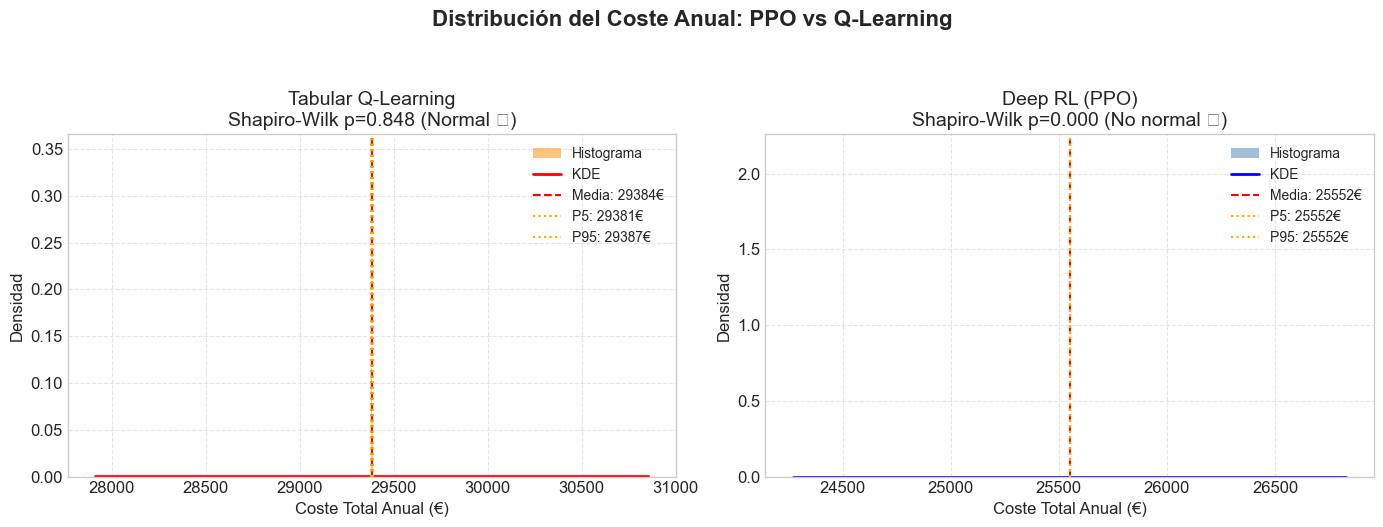

In [32]:
## 6. Distribución del Coste Final (Estabilidad de la Política)
# Comparamos visualmente la varianza del PPO frente al Q-Learning clásico.

def plot_comparativa_distribucion(data_dict, title="Distribución del Coste Anual: PPO vs Q-Learning"):
    fig, axes = plt.subplots(1, len(data_dict), figsize=(7 * len(data_dict), 5), squeeze=False)
    
    for ax, (label, final_costs) in zip(axes[0], data_dict.items()):
        # Histograma + KDE
        ax.hist(final_costs, bins=8, density=True, alpha=0.5,
                color='steelblue' if 'PPO' in label else 'darkorange', label='Histograma')
        
        # KDE suavizado
        kde = stats.gaussian_kde(final_costs)
        x_range = np.linspace(final_costs.min() * 0.95, final_costs.max() * 1.05, 200)
        ax.plot(x_range, kde(x_range), 'b-' if 'PPO' in label else 'r-', linewidth=2, label='KDE')
        
        # Líneas de media y percentiles
        mean_val   = np.mean(final_costs)
        p5, p95    = np.percentile(final_costs, [5, 95])
        
        ax.axvline(mean_val, color='red', linestyle='--', 
                   linewidth=1.5, label=f'Media: {mean_val:.0f}€')
        ax.axvline(p5, color='orange', linestyle=':',  
                   linewidth=1.5, label=f'P5: {p5:.0f}€')
        ax.axvline(p95, color='orange', linestyle=':',  
                   linewidth=1.5, label=f'P95: {p95:.0f}€')
        
        # Test de normalidad Shapiro-Wilk
        stat_sw, p_sw = stats.shapiro(final_costs)
        ax.set_title(f"{label}\nShapiro-Wilk p={p_sw:.3f} "
                     f"({'Normal ✓' if p_sw>0.05 else 'No normal ✗'})",
                     fontsize=14)
        ax.set_xlabel("Coste Total Anual (€)", fontsize=12)
        ax.set_ylabel("Densidad", fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Ejecutamos la gráfica
plot_comparativa_distribucion({
    "Tabular Q-Learning": costes_q_final,
    "Deep RL (PPO)": costes_ppo_final
})

In [33]:
## 7. Contraste de Hipótesis: Welch T-Test
# Verificamos si la diferencia en las medias de coste es estadísticamente significativa.

def welch_ttest_flat(sample_a, sample_b, label_a="Q-Learning", label_b="PPO"):
    t_stat, p_value = stats.ttest_ind(sample_a, sample_b, equal_var=False)
    
    print(f"\n{'='*60}")
    print(f"  Welch t-test: {label_a} vs {label_b} (Coste Anual Final)")
    print(f"{'='*60}")
    print(f"  {label_a:<12}: media={np.mean(sample_a):>8.2f}€  std={np.std(sample_a, ddof=1):>8.2f}€")
    print(f"  {label_b:<12}: media={np.mean(sample_b):>8.2f}€  std={np.std(sample_b, ddof=1):>8.2f}€")
    print(f"{'-'*60}")
    print(f"  t-statistic : {t_stat:.4f}")
    print(f"  p-value     : {p_value:.2e}")
    print(f"{'-'*60}")
    
    alpha = 0.05
    if p_value < alpha:
        mejor = label_a if np.mean(sample_a) < np.mean(sample_b) else label_b
        print(f"  → Diferencia SIGNIFICATIVA (p < {alpha}). {mejor} domina.")
    else:
        print(f"  → NO hay diferencia estadística significativa (p ≥ {alpha}).")

welch_ttest_flat(costes_q_final, costes_ppo_final)


  Welch t-test: Q-Learning vs PPO (Coste Anual Final)
  Q-Learning  : media=29384.02€  std=    1.89€
  PPO         : media=25551.61€  std=    0.79€
------------------------------------------------------------
  t-statistic : 8351.8368
  p-value     : 2.58e-83
------------------------------------------------------------
  → Diferencia SIGNIFICATIVA (p < 0.05). PPO domina.


## 6. Curvas aprendizaje

In [ ]:
import os
import sys
import numpy as np
import optuna
from pathlib import Path
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback

# --- CONFIGURACIÓN DE RUTAS (Ajusta igual que en tus otros scripts) ---
ruta_padre = Path(os.getcwd()).parent.parent
sys.path.append(str(ruta_padre))
sys.path.append(str(ruta_padre))

import pandas as pd
from custom_env_continuous_v2 import CustomEnvContinuousv2
from pymgrid.modules import GridModule, BatteryModule, LoadModule, RenewableModule
from pymgrid import Microgrid

# --- CARGA DE DATOS Y ENTORNO ---
ruta_precios = ruta_padre / "OBJETIVO1" / 'data' / 'external' / 'precio2025-peninsula.csv'
ruta_load = ruta_padre / "OBJETIVO1" / 'data' / 'raw' / 'load' / 'RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv'
ruta_pv = ruta_padre / "OBJETIVO1" / 'data' / 'processed' / 'pv_generacion_corregida_kw.csv'
ruta_script=ruta_padre / "OBJETIVO1" / "PPO"
df_precios = pd.read_csv(ruta_precios, sep=';')
precios_kwh = df_precios.sort_values('datetime')['value'].values / 1000.0
load_series = pd.read_csv(ruta_load).iloc[:, -1].values
pv_series = pd.read_csv(ruta_pv).iloc[:, -1].values
min_len = min(len(precios_kwh), len(load_series), len(pv_series), 8760)

def make_env(seed=0):
    def _init():
        grid_ts = pd.DataFrame({'import_price': precios_kwh[:min_len], 'export_price': precios_kwh[:min_len] * 0.5, 'co2_per_kwh': 0.0})
        grid = GridModule(max_import=200.0, max_export=200.0, time_series=grid_ts)
        battery = BatteryModule(min_capacity=10.0, max_capacity=200.0, max_charge=50.0, max_discharge=50.0, efficiency=0.9, init_soc=0.5)
        load = LoadModule(time_series=load_series[:min_len])
        pv = RenewableModule(time_series=pv_series[:min_len])
        mg = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])
        return CustomEnvContinuousv2(
            pymgrid_network=mg, horizon=8760, reward_scale_C=91.88,
            low_soc_penalty=2.0, low_soc_threshold=0.20,
            net_load_min=-40.64, net_load_max=62.45, price_min=0.02, price_max=0.425
        )
    return _init

# =====================================================================
# CALLBACK PERSONALIZADO PARA EXTRAER EL COSTE (€) CADA EPISODIO
# =====================================================================
class CostLoggingCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=8760, verbose=0):
        super().__init__(verbose)
        self.eval_env = eval_env  # Entorno crudo (no vectorizado) para testear
        self.eval_freq = eval_freq
        self.episode_costs = []

    def _on_step(self) -> bool:
        # Evaluamos cada vez que se cumple un año (8760 pasos)
        if self.num_timesteps % self.eval_freq == 0:
            obs, _ = self.eval_env.reset()
            done = False
            total_cost = 0.0
            
            while not done:
                action, _ = self.model.predict(obs, deterministic=True)
                obs, reward, term, trunc, info = self.eval_env.step(action)
                total_cost += info.get('cost', 0.0)
                done = term or trunc
                
            self.episode_costs.append(total_cost)
            print(f"Paso {self.num_timesteps} - Coste Evaluación: {total_cost:.2f} €")
        return True

# =====================================================================
# BUCLE DE ROBUSTEZ (MÚLTIPLES SEMILLAS)
# =====================================================================
if __name__ == "__main__":
    N_RUNS = 5              # Número de semillas (curvas independientes)
    TOTAL_TIMESTEPS = 525600 # 60 años/episodios (igual que tu Q-Learning)
    ruta_sq = ruta_padre / "OBJETIVO1" / 'PPO' 
    
    # 1. Recuperar mejores hiperparámetros de Optuna
    study = optuna.load_study(study_name="ppo_microgrid_v1", storage=f"sqlite:///{ruta_sq}/optuna_ppo_v1.db")
    best_params = study.best_params
    print("Iniciando robustez con los mejores parámetros:", best_params)

    # Matriz para guardar resultados: (n_runs, n_episodes)
    # 525600 steps / 8760 steps_por_episodio = 60 episodios
    n_episodes = TOTAL_TIMESTEPS // 8760
    ppo_costs_matrix = np.zeros((N_RUNS, n_episodes))

    try:
        for run in range(N_RUNS):
            print(f"\n--- INICIANDO RUN {run + 1}/{N_RUNS} (Semilla {run * 100}) ---")
            seed = run * 100
            
            train_env = make_vec_env(make_env(seed), n_envs=4, vec_env_cls=SubprocVecEnv)
            eval_env_raw = make_env(seed)()
            cost_callback = CostLoggingCallback(eval_env_raw, eval_freq=8760)

            model = PPO("MlpPolicy", train_env, **best_params, verbose=0, seed=seed)
            model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cost_callback)
            
            # Guardar resultados parciales en la matriz
            cur_len = len(cost_callback.episode_costs)
            ppo_costs_matrix[run, :cur_len] = cost_callback.episode_costs
            
            train_env.close()

            # --- MEJORA DE SEGURIDAD: Guardar después de cada RUN ---
            np.save(ruta_script / "ppo_learning_costs_partial.npy", ppo_costs_matrix)
            print(f"Progreso guardado tras Run {run + 1}")

    except KeyboardInterrupt:
        print("\nInterrupción detectada. Guardando lo que llevamos hasta ahora...")
    
    finally:
        # Guardado final definitivo
        np.save(ruta_script / "ppo_learning_costs.npy", ppo_costs_matrix)
        print("\n¡Matriz final/resultante guardada con éxito!")

Iniciando robustez con los mejores parámetros: {'n_steps': 512, 'batch_size': 256, 'learning_rate': 0.00015121236034329783, 'ent_coef': 2.7022809601519935e-07, 'clip_range': 0.2, 'n_epochs': 20, 'gamma': 0.9842365261981061}

--- INICIANDO RUN 1/5 (Semilla 0) ---
Paso 8760 - Coste Evaluación: 794375.64 €
Paso 17520 - Coste Evaluación: 923339.52 €
Paso 26280 - Coste Evaluación: 722109.19 €
Paso 35040 - Coste Evaluación: 385913.75 €
Paso 43800 - Coste Evaluación: 456740.32 €
Paso 52560 - Coste Evaluación: 324179.91 €
Paso 61320 - Coste Evaluación: 66087.32 €
Paso 70080 - Coste Evaluación: 30363.05 €
Paso 78840 - Coste Evaluación: 30561.25 €
Paso 87600 - Coste Evaluación: 29763.61 €
Paso 96360 - Coste Evaluación: 29780.58 €
Paso 105120 - Coste Evaluación: 29532.92 €
Paso 113880 - Coste Evaluación: 29025.14 €
Paso 122640 - Coste Evaluación: 28783.73 €
Paso 131400 - Coste Evaluación: 28667.41 €
Paso 140160 - Coste Evaluación: 28590.93 €
Paso 148920 - Coste Evaluación: 28669.29 €
Paso 157680 

In [43]:
# 1. CARGAR DATOS DE AMBOS ALGORITMOS
# (Sustituye la ruta de Q-learning por la tuya real)
q_cost_path=ruta_base / "OBJETIVO1" / "2_Q-learning" / "Resultados_Entrenamiento_Q" / "q_learning_costs_matrix.npy"
q_costs = np.load(q_cost_path) # Matriz (n_runs, 60) de Q-Learning
ppo_costs = np.load("ppo_learning_costs.npy") # Matriz (n_runs, 60) de PPO

# 2. DEFINIR EL DICCIONARIO CONJUNTO
# Esto alimenta tus funciones directamente
dict_comparativo = {
    "Tabular Q-Learning": q_costs,
    "PPO (Deep RL)": ppo_costs
}

FileNotFoundError: [Errno 2] No such file or directory: 'ppo_learning_costs.npy'

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# =====================================================================
# 1. FUNCIÓN: INTERVALOS DE CONFIANZA (Media)
# =====================================================================
def plot_confidence_interval(data_dict, title="Curvas de Aprendizaje (95% CI)"):
    plt.figure(figsize=(10, 6))
    
    # Paleta de colores para diferenciar bien PPO de Q-Learning
    colores = {'Tabular Q-Learning': 'darkorange', 'PPO (Deep RL)': 'steelblue'}
    
    for label, data in data_dict.items():
        n_runs, n_eps = data.shape
        mean_costs = np.mean(data, axis=0)
        std_costs  = np.std(data, axis=0, ddof=1)  # ddof=1 para muestra
        
        # t-distribution (más correcto que Z para muestras finitas)
        t_crit = stats.t.ppf(0.975, df=n_runs - 1)
        ci = t_crit * (std_costs / np.sqrt(n_runs))
        
        episodes = np.arange(1, n_eps + 1)
        color = colores.get(label, 'green') # Color por defecto si cambia el nombre
        
        plt.plot(episodes, mean_costs, label=f"{label} (Media)", linewidth=2, color=color)
        plt.fill_between(episodes, mean_costs - ci, mean_costs + ci,
                         alpha=0.2, color=color, label=f"{label} (95% CI)")
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Episodios (Años Simulados)", fontsize=12)
    plt.ylabel("Coste Total Anual (€)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =====================================================================
# 2. FUNCIONES: INTERVALOS DE TOLERANCIA (Rango de Operación)
# =====================================================================
def tolerance_interval_normal(data, coverage=0.95, confidence=0.95):
    """
    Tolerance interval paramétrico (asume normalidad).
    Devuelve (lower, upper) para cada episodio.
    coverage   = proporción de la población a cubrir (β)
    confidence = nivel de confianza del intervalo (1-α)
    """
    n = data.shape[0]
    mean = np.mean(data, axis=0)
    std  = np.std(data, axis=0, ddof=1)
    
    # Factor k de tolerance interval (Aproximación práctica con chi2)
    z_beta   = stats.norm.ppf((1 + coverage) / 2)      
    chi2_val = stats.chi2.ppf(1 - confidence, df=n - 1)
    k = np.sqrt((n - 1) * (1 + 1/n) * z_beta**2 / chi2_val)
    
    return mean - k * std, mean + k * std

def plot_tolerance_interval(data_dict, title="Intervalos de Tolerancia (95% Cobertura / 95% Confianza)"):
    plt.figure(figsize=(10, 6))
    
    colores = {'Tabular Q-Learning': 'darkorange', 'PPO (Deep RL)': 'steelblue'}
    
    for label, data in data_dict.items():
        n_eps = data.shape[1]
        mean_costs = np.mean(data, axis=0)
        low_ti, high_ti = tolerance_interval_normal(data)
        
        episodes = np.arange(1, n_eps + 1)
        color = colores.get(label, 'green')
        
        plt.plot(episodes, mean_costs, label=f"{label} (Media)", linewidth=2, color=color)
        plt.fill_between(episodes, low_ti, high_ti, alpha=0.15,
                         color=color, label=f"{label} (95%/95% TI)")
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Episodios (Años Simulados)", fontsize=12)
    plt.ylabel("Coste Total Anual (€)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. EJECUCIÓN DE LAS GRÁFICAS
# =====================================================================
plot_confidence_interval(dict_comparativo)
plot_tolerance_interval(dict_comparativo)